# Storytelling de análisis táctico - AutoTec

Este notebook presenta el storytelling de los análisis tácticos desarrollados en el dashboard de Streamlit para el proyecto AutoTec.

El objetivo es interpretar los gráficos del nivel táctico, describiendo lo que muestran los datos de manera concreta, sin realizar suposiciones externas. El análisis se enfoca en variables como marca, precio, kilometraje, combustible y ciudad, con el fin de apoyar decisiones comerciales basadas en información observable.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("datos_autotec_dashboard.csv")

df = df.dropna(subset=["marca", "precio_num", "km_num", "year_limpio"])

if "ciudad" not in df.columns and "ciudad_o_comuna" in df.columns:
    df["ciudad"] = df["ciudad_o_comuna"]

df.head()

,marca,modelo,year,precio,kilometraje,combustible,ciudad,url,precio_num,km_num,year_limpio
0,audi,A1 Sportback 30 Tfsi Sport,2024,21990000.0,27294.0,bencina,santiago,https://automoviles.emol.com/venta/autos/audi-...,21997.0,272940.0,2024
1,audi,A1 Sportback 30 Tfsi Sport,2024,21990000.0,11766.0,bencina,santiago,https://automoviles.emol.com/venta/autos/audi-...,21997.0,117660.0,2024
2,audi,A3 2.0 Tfsi Sport Auto,2018,18990000.0,84917.0,bencina,santiago,https://automoviles.emol.com/venta/autos/audi-...,18997.0,849170.0,2018
3,audi,A3 1.4 35 Tfsi Stronic Auto,2018,15890000.0,93687.0,bencina,santiago,https://automoviles.emol.com/venta/autos/audi-...,15897.0,936870.0,2018
4,audi,A4 2.0 Tfsi 35 S-tronic,2024,29490000.0,45021.0,bencina,santiago,https://automoviles.emol.com/venta/autos/audi-...,29497.0,450210.0,2024


## Preparación de variables tácticas

Para realizar el análisis táctico se utilizan variables asociadas a la gestión comercial de los vehículos, tales como marca, precio, kilometraje, combustible y ciudad.

Además, se crean rangos de kilometraje y categorías de precio para facilitar la comparación entre segmentos del mercado. Estas variables permiten observar diferencias en los precios promedio, detectar grupos de vehículos bajo el promedio y comparar comportamientos según ciudad y tipo de combustible.

In [2]:
df_tactico = df.copy()

df_tactico["rango_kilometraje"] = pd.cut(
    df_tactico["km_num"],
    bins=[
        0,
        50000,
        100000,
        150000,
        200000,
        df_tactico["km_num"].max()
    ],
    labels=[
        "0 - 50.000 km",
        "50.001 - 100.000 km",
        "100.001 - 150.000 km",
        "150.001 - 200.000 km",
        "Más de 200.000 km"
    ],
    include_lowest=True
)

df_tactico["categoria_precio"] = pd.cut(
    df_tactico["precio_num"],
    bins=[
        0,
        df_tactico["precio_num"].quantile(0.33),
        df_tactico["precio_num"].quantile(0.66),
        df_tactico["precio_num"].max()
    ],
    labels=[
        "Precio bajo",
        "Precio medio",
        "Precio alto"
    ],
    include_lowest=True
)

df_tactico[["marca", "precio_num", "km_num", "rango_kilometraje", "categoria_precio"]].head()

,marca,precio_num,km_num,rango_kilometraje,categoria_precio
0,audi,21997.0,272940.0,Más de 200.000 km,Precio medio
1,audi,21997.0,117660.0,100.001 - 150.000 km,Precio medio
2,audi,18997.0,849170.0,Más de 200.000 km,Precio medio
3,audi,15897.0,936870.0,Más de 200.000 km,Precio medio
4,audi,29497.0,450210.0,Más de 200.000 km,Precio alto


## Análisis 1: Desviación del precio promedio por marca

Este análisis compara el precio promedio de cada marca con el precio promedio general de la base. La finalidad es observar qué marcas se ubican por encima o por debajo del promedio general de precios.

Este gráfico permite identificar diferencias porcentuales entre marcas, considerando la variable precio como principal referencia táctica. Las marcas con desviación positiva presentan precios promedio superiores al promedio general, mientras que las marcas con desviación negativa se ubican bajo ese promedio.

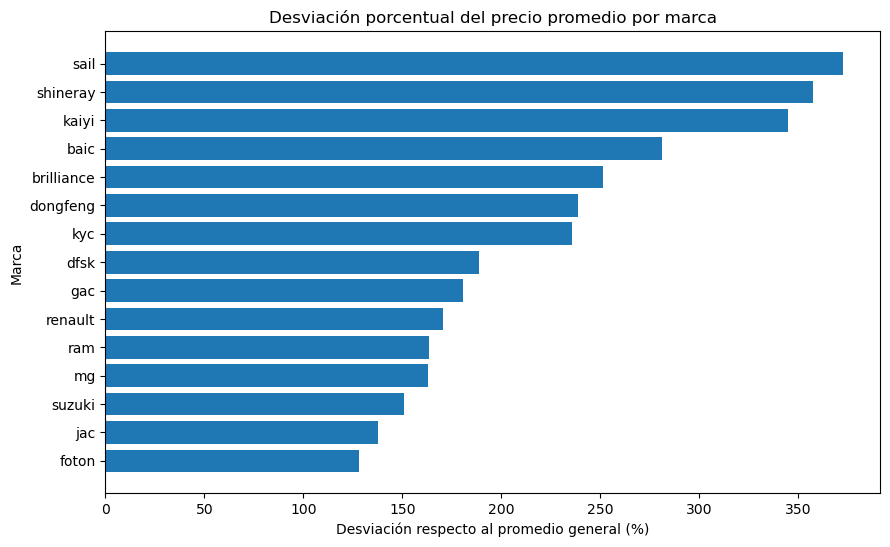

,marca,precio_promedio,cantidad_autos,desviacion_pct
53,sail,9.290000e+07,1,372.809034
56,shineray,8.990000e+07,1,357.540713
32,kaiyi,8.740000e+07,2,344.817111
1,baic,7.490000e+07,1,281.199103
3,brilliance,6.900000e+07,1,251.171403
12,dongfeng,6.656663e+07,3,238.786928
34,kyc,6.593333e+07,3,235.563785
10,dfsk,5.673456e+07,10,188.747170
19,gac,5.510475e+07,6,180.452348
52,renault,5.318235e+07,20,170.668391


In [3]:
precio_promedio_general = df_tactico["precio_num"].mean()

df_marca_precio = df_tactico.groupby("marca")["precio_num"].agg(
    precio_promedio="mean",
    cantidad_autos="count"
).reset_index()

df_marca_precio["desviacion_pct"] = (
    (df_marca_precio["precio_promedio"] - precio_promedio_general)
    / precio_promedio_general
) * 100

df_marca_precio = df_marca_precio.sort_values("desviacion_pct", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_marca_precio["marca"].tail(15), df_marca_precio["desviacion_pct"].tail(15))
plt.axvline(0, linestyle="--")
plt.title("Desviación porcentual del precio promedio por marca")
plt.xlabel("Desviación respecto al promedio general (%)")
plt.ylabel("Marca")
plt.show()

df_marca_precio.sort_values("desviacion_pct", ascending=False).head(10)

### Storytelling del análisis 1

El gráfico muestra la desviación porcentual del precio promedio por marca respecto al promedio general de la base analizada. Las barras ubicadas hacia la derecha del valor cero representan marcas con precios promedio superiores al promedio general, mientras que las barras hacia la izquierda representan marcas con precios promedio inferiores.

Desde una mirada táctica, este análisis permite comparar el posicionamiento de precios entre marcas. Las marcas con mayor desviación positiva pueden asociarse a vehículos con precios promedio más altos dentro de la base, mientras que aquellas con desviación negativa presentan valores promedio más bajos en comparación con el conjunto analizado.

Este resultado ayuda a distinguir diferencias comerciales entre marcas y sirve como apoyo para revisar estrategias de publicación, comparación de precios y segmentación del inventario.

## Análisis 2: Autos bajo el precio promedio según rango de kilometraje

Este análisis observa la relación entre kilometraje y precio, agrupando los vehículos por rangos de kilometraje. Para cada rango se calcula el precio promedio y luego se identifica qué porcentaje de autos se encuentra bajo ese promedio.

La finalidad es detectar en qué rangos de kilometraje existe mayor concentración de vehículos con precios inferiores al promedio del propio segmento.

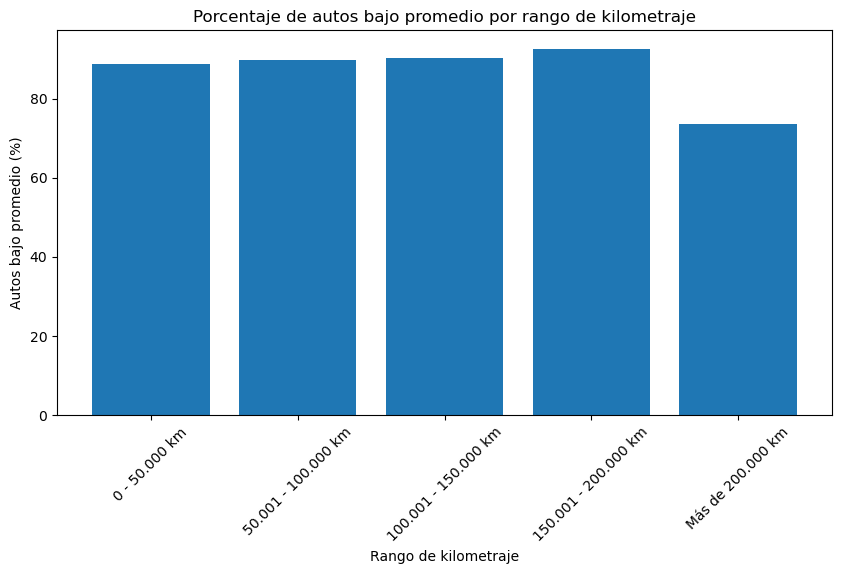

,rango_kilometraje,cantidad_autos,precio_promedio,porcentaje_bajo_promedio
0,0 - 50.000 km,44,9.395058e+06,88.636364
1,50.001 - 100.000 km,59,9.181628e+06,89.830508
2,100.001 - 150.000 km,71,7.034418e+06,90.140845
3,150.001 - 200.000 km,81,6.550799e+06,92.592593
4,Más de 200.000 km,1733,2.139418e+07,73.571841


In [4]:
precio_promedio_rango = df_tactico.groupby(
    "rango_kilometraje",
    observed=True
)["precio_num"].transform("mean")

df_tactico["precio_promedio_rango"] = precio_promedio_rango

df_tactico["bajo_promedio_rango"] = (
    df_tactico["precio_num"] < df_tactico["precio_promedio_rango"]
)

df_km = df_tactico.groupby("rango_kilometraje", observed=True).agg(
    cantidad_autos=("precio_num", "count"),
    precio_promedio=("precio_num", "mean"),
    porcentaje_bajo_promedio=("bajo_promedio_rango", "mean")
).reset_index()

df_km["porcentaje_bajo_promedio"] = df_km["porcentaje_bajo_promedio"] * 100

plt.figure(figsize=(10, 5))
plt.bar(
    df_km["rango_kilometraje"].astype(str),
    df_km["porcentaje_bajo_promedio"]
)
plt.title("Porcentaje de autos bajo promedio por rango de kilometraje")
plt.xlabel("Rango de kilometraje")
plt.ylabel("Autos bajo promedio (%)")
plt.xticks(rotation=45)
plt.show()

df_km

### Storytelling del análisis 2

El gráfico muestra el porcentaje de vehículos que se encuentran bajo el precio promedio dentro de cada rango de kilometraje. Esto permite comparar segmentos de uso del vehículo y observar en qué grupos existe una mayor proporción de autos con precios inferiores al promedio del mismo rango.

A nivel táctico, este análisis es útil porque relaciona dos variables importantes para la gestión comercial: kilometraje y precio. Los rangos con mayor porcentaje de autos bajo el promedio pueden requerir una revisión más detallada de sus condiciones comerciales, ya que concentran vehículos con valores menores respecto a su propio segmento.

Este análisis permite apoyar decisiones relacionadas con revisión de publicaciones, ajustes de precio y clasificación del inventario según nivel de uso.

## Análisis 3: Precio promedio por tipo de combustible y ciudad

Este análisis compara el precio promedio de los vehículos según ciudad y tipo de combustible. Para facilitar la visualización, se consideran las ciudades y combustibles con mayor presencia dentro de la base.

El objetivo es observar diferencias de precio entre zonas y tipos de combustible, utilizando variables relevantes para la toma de decisiones comerciales.

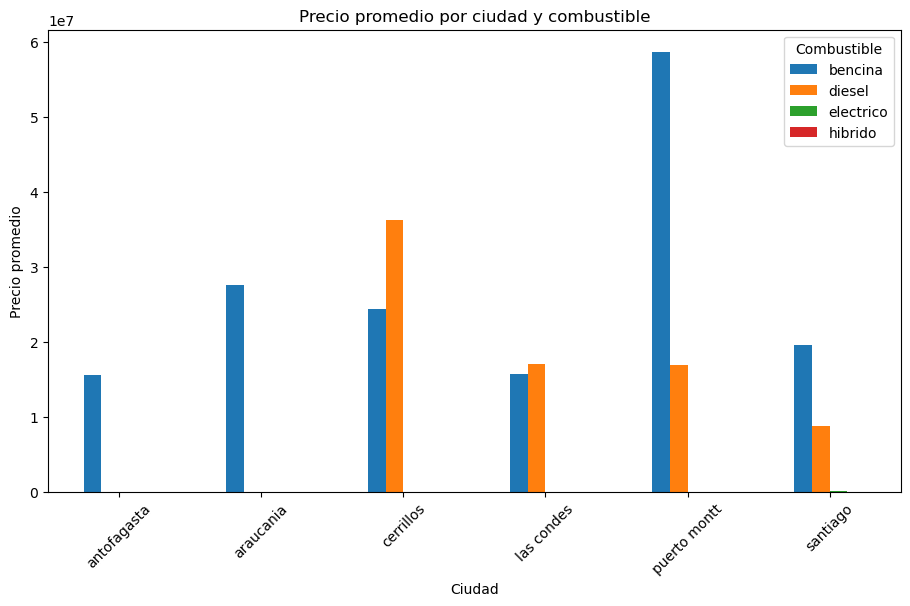

,ciudad,combustible,precio_num
0,antofagasta,bencina,1.550651e+07
1,antofagasta,diesel,1.506950e+04
2,antofagasta,hibrido,1.399700e+04
3,araucania,bencina,2.759821e+07
4,araucania,diesel,1.444700e+04
5,cerrillos,bencina,2.441747e+07
6,cerrillos,diesel,3.621752e+07
7,las condes,bencina,1.565538e+07
8,las condes,diesel,1.709110e+07
9,las condes,hibrido,2.049700e+04


In [5]:
if "combustible" in df_tactico.columns and "ciudad" in df_tactico.columns:
    top_ciudades = df_tactico["ciudad"].value_counts().head(6).index
    top_combustibles = df_tactico["combustible"].value_counts().head(4).index

    df_ciudad_comb = df_tactico[
        (df_tactico["ciudad"].isin(top_ciudades)) &
        (df_tactico["combustible"].isin(top_combustibles))
    ]

    df_precio_ciudad = df_ciudad_comb.groupby(
        ["ciudad", "combustible"]
    )["precio_num"].mean().reset_index()

    tabla_pivot = df_precio_ciudad.pivot(
        index="ciudad",
        columns="combustible",
        values="precio_num"
    )

    tabla_pivot.plot(kind="bar", figsize=(11, 6))
    plt.title("Precio promedio por ciudad y combustible")
    plt.xlabel("Ciudad")
    plt.ylabel("Precio promedio")
    plt.xticks(rotation=45)
    plt.legend(title="Combustible")
    plt.show()

    display(df_precio_ciudad)
else:
    print("No se encuentran disponibles las columnas combustible y ciudad para este análisis.")

### Storytelling del análisis 3

El gráfico compara el precio promedio de los vehículos considerando simultáneamente la ciudad y el tipo de combustible. Cada grupo permite observar diferencias de precio entre combustibles dentro de una misma ciudad y también comparar el comportamiento entre distintas ciudades.

Desde el nivel táctico, este análisis permite visualizar cómo cambia el precio promedio dependiendo de la combinación entre ubicación y combustible. Esto entrega una mirada más completa que analizar solo el precio o solo el combustible por separado, ya que incorpora una dimensión territorial.

El resultado puede apoyar decisiones comerciales relacionadas con segmentación por ciudad, comparación de precios entre zonas y revisión del comportamiento de los vehículos según su tipo de combustible.

## Conclusión general del análisis táctico

El análisis táctico realizado permite observar diferencias relevantes en el comportamiento comercial de los vehículos usados dentro de la base AutoTec. A través de los gráficos se revisaron tres dimensiones principales: la desviación de precios por marca, la relación entre precio y kilometraje, y la comparación del precio promedio según ciudad y tipo de combustible.

En conjunto, estos análisis permiten comprender mejor cómo se distribuyen los precios dentro del mercado observado. La comparación por marca permite identificar diferencias de posicionamiento; el análisis por kilometraje ayuda a detectar segmentos con mayor proporción de autos bajo el promedio; y la comparación por ciudad y combustible permite observar variaciones comerciales según ubicación y características del vehículo.

Estos resultados sirven como base para la toma de decisiones tácticas, especialmente en aspectos relacionados con la publicación de vehículos, revisión de precios, clasificación del inventario y análisis de segmentos de mercado.